# Analyse Eclipse Relperm .INC file

In [ ]:
# Import Python libraries
!pip install -q -U kaleido==0.2.1 -q -U skimpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.0/118.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.2/106.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: jupyter-client
    Found existing installation: jupyter_client 7.4.9
    Uninstalling jupyter_client-7.4.9:
      Successfully uninstalled jupyter_client-7.4.9
  Attempting uninstall: ipykernel


In [ ]:
import os
from google.colab import drive
from pathlib import Path

# Mount Google Drive (run once per session)
drive.mount("/content/drive")

# Data directory (adjust if you move the notebook)
source = Path("/content/drive/MyDrive/Colab Notebooks/Petroleum Engineering/Data/Norne/INCLUDE/RELPERM/")
dest = Path("/content/drive/MyDrive/Colab Notebooks/Petroleum Engineering/Output/Norne/")

# Create directory if it does not exist
os.makedirs(dest, exist_ok=True)

print("Source directory:", source)
print("Output directory:", dest)

Mounted at /content/drive
Source directory: /content/drive/MyDrive/Colab Notebooks/Petroleum Engineering/Data/Norne/INCLUDE/RELPERM
Output directory: /content/drive/MyDrive/Colab Notebooks/Petroleum Engineering/Output/Norne


In [ ]:
from pathlib import Path

# All entries (files + subdirs)
#for p in source.iterdir():
#    print(p)

# Only files
for p in source.iterdir():
    if p.is_file():
        print(p)

/content/drive/MyDrive/Colab Notebooks/Petroleum Engineering/Data/Norne/INCLUDE/RELPERM/SCAL_NORNE.INC


## 1.0 Parse SWOF and SGOF into dataframes ##

In [ ]:
import re
import pandas as pd
from pathlib import Path

text = Path(source / "SCAL_NORNE.INC").read_text()

def extract_keyword_block(keyword, text):
    pat = rf"{keyword}\s*(.*?)/"
    m = re.search(pat, text, flags=re.S)
    if not m:
        return ""
    return m.group(1)

def clean_lines(block):
    out = []
    for ln in block.splitlines():
        if "--" in ln:
            ln = ln.split("--", 1)[0]
        ln = ln.strip()
        if not ln:
            continue
        out.append(ln)
    return out

swof_block = extract_keyword_block("SWOF", text)
sgof_block = extract_keyword_block("SGOF", text)

swof_lines = clean_lines(swof_block)
sgof_lines = clean_lines(sgof_block)

def parse_swof(lines):
    # Sw, Krw, Kro, Pc
    recs = []
    for ln in lines:
        parts = ln.split()
        if len(parts) < 4:
            continue
        sw  = float(parts[0])
        krw = float(parts[1])
        kro = float(parts[2])
        pc  = float(parts[3])
        recs.append({"Sw": sw, "Krw": krw, "Kro": kro, "Pcow": pc})
    return pd.DataFrame(recs).sort_values("Sw").reset_index(drop=True)

def parse_sgof(lines):
    # Sg, Krg, Kro, Pc
    recs = []
    for ln in lines:
        parts = ln.split()
        if len(parts) < 4:
            continue
        sg  = float(parts[0])
        krg = float(parts[1])
        kro = float(parts[2])
        pc  = float(parts[3])
        recs.append({"Sg": sg, "Krg": krg, "Kro": kro, "Pcog": pc})
    return pd.DataFrame(recs).sort_values("Sg").reset_index(drop=True)

swof_df = parse_swof(swof_lines)
sgof_df = parse_sgof(sgof_lines)

print(swof_df.head())
print(sgof_df.head())

       Sw      Krw      Kro     Pcow
0  0.0000  0.00000  1.00000  3.75633
1  0.0001  0.00000  0.99900  3.75632
2  0.0500  0.00086  0.84782  1.86981
3  0.1000  0.00263  0.69746  1.23731
4  0.1500  0.00524  0.55717  0.91821
     Sg       Krg       Kro  Pcog
0  0.00  0.000000  1.000000   0.0
1  0.05  0.001655  0.806888   0.0
2  0.10  0.006913  0.633562   0.0
3  0.15  0.016213  0.485506   0.0
4  0.20  0.029990  0.364043   0.0


In [ ]:
from skimpy import skim

skim(sgof_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 22     │ │ float64     │ 4     │                                                          │
│ │ Number of columns │ 4      │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     number                                                      │
│ ┏━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column   ┃ NA  ┃ NA %   ┃ mean     ┃ sd       ┃ p0  ┃ p25         ┃ p50       ┃ p75      ┃ p100  ┃ hist    ┃  │
│ ┡━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━┩  │
│ │ Sg       │   0 │      0 │   0.5227 │    0.321 │   0 │      0.2625 │     0.525 │   0.7875 │     1 │ ▆▅▅▆▅█  │  │
│ │ Krg      │   0 │      0 │   0.3484 │     0.33 │   0 │     0.05463 │    0.2517 │    0.594 │  0.95 │ █▃▃▂▂▃  │  │
│ │ Kro      │   0 │      0 │   0.1887 │   0.2912 │   0 │    0.001487 │   0.03468 │   0.2489 │     1 │ █▁▁▁▁▁  │  │
│ │ Pcog     │   0 │      0 │        0 │        0 │   0 │           0 │         0 │        0 │     0 │     █   │  │
│ └──────────┴─────┴────────┴──────────┴──────────┴─────┴─────────────┴───────────┴──────────┴───────┴─────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [ ]:
skim(swof_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 22     │ │ float64     │ 4     │                                                          │
│ │ Number of columns │ 4      │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     number                                                      │
│ ┏━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column   ┃ NA  ┃ NA %  ┃ mean     ┃ sd      ┃ p0        ┃ p25       ┃ p50      ┃ p75     ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │ Sw       │   0 │     0 │   0.4773 │   0.321 │         0 │    0.2125 │    0.475 │  0.7375 │      1 │ █▅▅▆▅▆ │  │
│ │ Krw      │   0 │     0 │   0.1308 │  0.1605 │         0 │  0.009923 │  0.05515 │  0.2019 │    0.5 │ █▁▁▁▁▁ │  │
│ │ Kro      │   0 │     0 │   0.2556 │  0.3441 │         0 │  0.004343 │  0.06969 │  0.4065 │      1 │ █▂▁▁▁▂ │  │
│ │ Pcow     │   0 │     0 │   0.7314 │   1.073 │   0.04408 │    0.1447 │    0.299 │  0.6917 │  3.756 │ █▂   ▁ │  │
│ └──────────┴─────┴───────┴──────────┴─────────┴───────────┴───────────┴──────────┴─────────┴────────┴────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

This gives you clean water–oil and gas–oil relperm and capillary pressure tables.

## 2.0 Quick SCAL metrics and QA/QC ##

In [ ]:
def summarize_swof(df):
    swc = df.loc[df["Krw"] <= 1e-5, "Sw"].min()
    sor = df.loc[df["Kro"] <= 1e-3, "Sw"].max()
    return {
        "Sw_min": df["Sw"].min(),
        "Sw_max": df["Sw"].max(),
        "krw_max": df["Krw"].max(),
        "kro_max": df["Kro"].max(),
        "Pc_min": df["Pcow"].min(),
        "Pc_max": df["Pcow"].max(),
        "Swc_est": swc,
        "Sorw_est": sor,
    }

def summarize_sgof(df):
    sgc = df.loc[df["Krg"] <= 1e-5, "Sg"].min()
    sorg = df.loc[df["Kro"] <= 1e-3, "Sg"].max()
    return {
        "Sg_min": df["Sg"].min(),
        "Sg_max": df["Sg"].max(),
        "krg_max": df["Krg"].max(),
        "kro_max": df["Kro"].max(),
        "Pc_min": df["Pcog"].min(),
        "Pc_max": df["Pcog"].max(),
        "Sgc_est": sgc,
        "Sorg_est": sorg,
    }

print("SWOF summary:", summarize_swof(swof_df))
print("SGOF summary:", summarize_sgof(sgof_df))

SWOF summary: {'Sw_min': 0.0, 'Sw_max': 1.0, 'krw_max': 0.5, 'kro_max': 1.0, 'Pc_min': 0.04408, 'Pc_max': 3.75633, 'Swc_est': 0.0, 'Sorw_est': 1.0}
SGOF summary: {'Sg_min': 0.0, 'Sg_max': 1.0, 'krg_max': 0.95, 'kro_max': 1.0, 'Pc_min': 0.0, 'Pc_max': 0.0, 'Sgc_est': 0.0, 'Sorg_est': 1.0}


Extend the summaries to include endpoint saturations, mobility ratios at a reference point, curve resolution and simple monotonicity flags.

In [ ]:
import numpy as np

def _monotone_flag(y, direction="increasing", tol=0.0):
    dy = np.diff(np.asarray(y, dtype=float))
    if direction == "increasing":
        return bool(np.all(dy >= -tol))
    else:
        return bool(np.all(dy <= tol))


def summarize_swof(df, krw_tol=1e-5, kro_tol=1e-3):
    df = df.sort_values("Sw").reset_index(drop=True)

    sw_min = df["Sw"].min()
    sw_max = df["Sw"].max()

    swc = df.loc[df["Krw"] <= krw_tol, "Sw"].min()    # connate water
    sor = df.loc[df["Kro"] <= kro_tol, "Sw"].max()    # residual oil

    # endpoint relperms at connate and residual conditions
    krw_end = df.loc[df["Sw"] == sw_max, "Krw"].iloc[0]
    kro_end = df.loc[df["Sw"] == sw_min, "Kro"].iloc[0]

    # mobility ratios at mid‑saturation (quick feel for flood behaviour)
    sw_mid = 0.5 * (swc + sor) if np.isfinite(swc) and np.isfinite(sor) else df["Sw"].median()
    row_mid = df.iloc[(df["Sw"] - sw_mid).abs().argmin()]
    mob_w_mid = row_mid["Krw"]  # assume unit viscosity for quick ratio
    mob_o_mid = row_mid["Kro"]
    mob_ratio_mid = mob_w_mid / mob_o_mid if mob_o_mid > 0 else np.nan

    # monotonicity flags
    krw_mono = _monotone_flag(df["Krw"], "increasing", tol=0)
    kro_mono = _monotone_flag(df["Kro"], "decreasing", tol=0)
    pc_mono  = _monotone_flag(df["Pcow"], "decreasing", tol=0)

    return {
        "n_points": len(df),
        "Sw_min": sw_min,
        "Sw_max": sw_max,
        "krw_max": df["Krw"].max(),
        "kro_max": df["Kro"].max(),
        "Pc_min": df["Pcow"].min(),
        "Pc_max": df["Pcow"].max(),
        "Swc_est": swc,
        "Sorw_est": sor,
        "krw_endpoint_at_Swmax": krw_end,
        "kro_endpoint_at_Swmin": kro_end,
        "Sw_mid": sw_mid,
        "mob_w_mid": mob_w_mid,
        "mob_o_mid": mob_o_mid,
        "mob_ratio_mid": mob_ratio_mid,
        "Krw_monotone_inc": krw_mono,
        "Kro_monotone_dec": kro_mono,
        "Pc_monotone_dec": pc_mono,
    }


def summarize_sgof(df, krg_tol=1e-5, kro_tol=1e-3):
    df = df.sort_values("Sg").reset_index(drop=True)

    sg_min = df["Sg"].min()
    sg_max = df["Sg"].max()

    sgc = df.loc[df["Krg"] <= krg_tol, "Sg"].min()    # connate gas
    sorg = df.loc[df["Kro"] <= kro_tol, "Sg"].max()   # residual oil to gas

    krg_end = df.loc[df["Sg"] == sg_max, "Krg"].iloc[0]
    kro_end = df.loc[df["Sg"] == sg_min, "Kro"].iloc[0]

    sg_mid = 0.5 * (sgc + sorg) if np.isfinite(sgc) and np.isfinite(sorg) else df["Sg"].median()
    row_mid = df.iloc[(df["Sg"] - sg_mid).abs().argmin()]
    mob_g_mid = row_mid["Krg"]
    mob_o_mid = row_mid["Kro"]
    mob_ratio_mid = mob_g_mid / mob_o_mid if mob_o_mid > 0 else np.nan

    krg_mono = _monotone_flag(df["Krg"], "increasing", tol=0)
    kro_mono = _monotone_flag(df["Kro"], "decreasing", tol=0)
    pc_mono  = _monotone_flag(df["Pcog"], "increasing", tol=0)  # Pcog often ≥0 and rising

    return {
        "n_points": len(df),
        "Sg_min": sg_min,
        "Sg_max": sg_max,
        "krg_max": df["Krg"].max(),
        "kro_max": df["Kro"].max(),
        "Pc_min": df["Pcog"].min(),
        "Pc_max": df["Pcog"].max(),
        "Sgc_est": sgc,
        "Sorg_est": sorg,
        "krg_endpoint_at_Sgmax": krg_end,
        "kro_endpoint_at_Sgmin": kro_end,
        "Sg_mid": sg_mid,
        "mob_g_mid": mob_g_mid,
        "mob_o_mid": mob_o_mid,
        "mob_ratio_mid": mob_ratio_mid,
        "Krg_monotone_inc": krg_mono,
        "Kro_monotone_dec": kro_mono,
        "Pc_monotone_inc": pc_mono,
    }


print("SWOF summary:", summarize_swof(swof_df))
print("SGOF summary:", summarize_sgof(sgof_df))

SWOF summary: {'n_points': 22, 'Sw_min': 0.0, 'Sw_max': 1.0, 'krw_max': 0.5, 'kro_max': 1.0, 'Pc_min': 0.04408, 'Pc_max': 3.75633, 'Swc_est': 0.0, 'Sorw_est': 1.0, 'krw_endpoint_at_Swmax': np.float64(0.5), 'kro_endpoint_at_Swmin': np.float64(1.0), 'Sw_mid': 0.5, 'mob_w_mid': np.float64(0.0625), 'mob_o_mid': np.float64(0.05565), 'mob_ratio_mid': np.float64(1.1230907457322552), 'Krw_monotone_inc': True, 'Kro_monotone_dec': True, 'Pc_monotone_dec': True}
SGOF summary: {'n_points': 22, 'Sg_min': 0.0, 'Sg_max': 1.0, 'krg_max': 0.95, 'kro_max': 1.0, 'Pc_min': 0.0, 'Pc_max': 0.0, 'Sgc_est': 0.0, 'Sorg_est': 1.0, 'krg_endpoint_at_Sgmax': np.float64(0.95), 'kro_endpoint_at_Sgmin': np.float64(1.0), 'Sg_mid': 0.5, 'mob_g_mid': np.float64(0.225368), 'mob_o_mid': np.float64(0.042324), 'mob_ratio_mid': np.float64(5.324827521028259), 'Krg_monotone_inc': True, 'Kro_monotone_dec': True, 'Pc_monotone_inc': True}


Monotonicity checks (to spot noisy lab points) can reuse the pattern from the PVT analysis:

In [ ]:
import numpy as np

def find_non_monotone(df, x, y, direction="increasing"):
    df = df.sort_values(x)
    dy = np.diff(df[y].values)
    if direction == "increasing":
        bad = np.where(dy < 0)[0] + 1
    else:
        bad = np.where(dy > 0)[0] + 1
    return df.iloc[bad]

viol_krw = find_non_monotone(swof_df, "Sw", "Krw", "increasing")
viol_kro_w = find_non_monotone(swof_df, "Sw", "Kro", "decreasing")
viol_krg = find_non_monotone(sgof_df, "Sg", "Krg", "increasing")
viol_kro_g = find_non_monotone(sgof_df, "Sg", "Kro", "decreasing")
print(len(viol_krw), len(viol_kro_w), len(viol_krg), len(viol_kro_g))

0 0 0 0


## 3.0 Optional: basic plotting for visual inspection ##

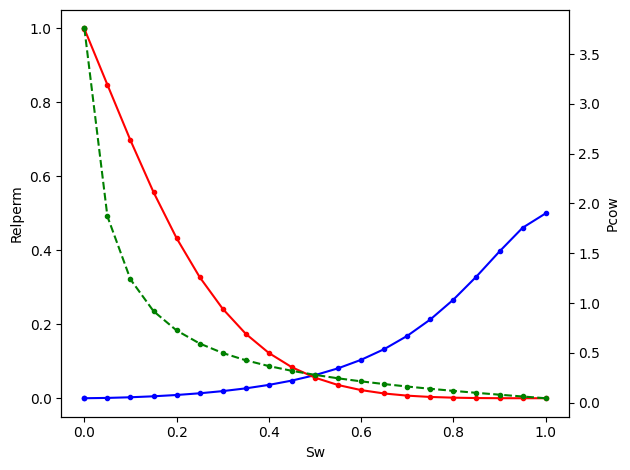

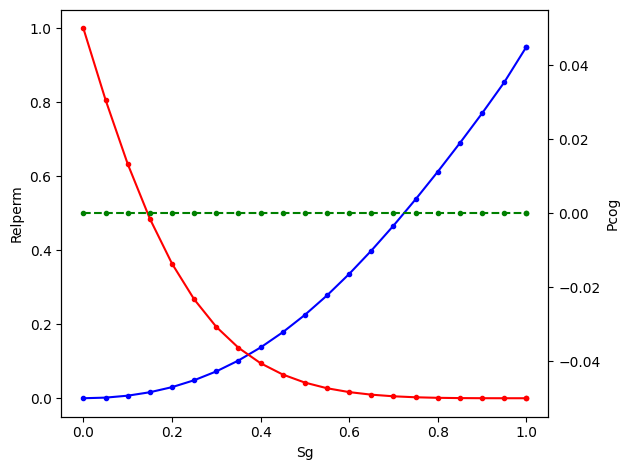

In [ ]:
import matplotlib.pyplot as plt

# Water–oil
fig, ax1 = plt.subplots()
ax1.plot(swof_df["Sw"], swof_df["Krw"], "b.-", label="Krw")
ax1.plot(swof_df["Sw"], swof_df["Kro"], "r.-", label="Kro")
ax1.set_xlabel("Sw")
ax1.set_ylabel("Relperm")
ax2 = ax1.twinx()
ax2.plot(swof_df["Sw"], swof_df["Pcow"], "g.--", label="Pcow")
ax2.set_ylabel("Pcow")
fig.tight_layout()

# Gas–oil
fig, ax1 = plt.subplots()
ax1.plot(sgof_df["Sg"], sgof_df["Krg"], "b.-", label="Krg")
ax1.plot(sgof_df["Sg"], sgof_df["Kro"], "r.-", label="Kro")
ax1.set_xlabel("Sg")
ax1.set_ylabel("Relperm")
ax2 = ax1.twinx()
ax2.plot(sgof_df["Sg"], sgof_df["Pcog"], "g.--", label="Pcog")
ax2.set_ylabel("Pcog")
fig.tight_layout()
plt.show()

In [ ]:
import plotly
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "colab"
import plotly.express as px
from plotly.subplots import make_subplots

# ---------- Water–oil: Sw vs Krw, Kro, Pcow ----------

fig_sw = make_subplots(specs=[[{"secondary_y": True}]])

fig_sw.add_trace(
    go.Scatter(
        x=swof_df["Sw"],
        y=swof_df["Krw"],
        mode="lines+markers",
        name="Krw",
        line=dict(color="blue")
    ),
    secondary_y=False,
)

fig_sw.add_trace(
    go.Scatter(
        x=swof_df["Sw"],
        y=swof_df["Kro"],
        mode="lines+markers",
        name="Kro",
        line=dict(color="red")
    ),
    secondary_y=False,
)

fig_sw.add_trace(
    go.Scatter(
        x=swof_df["Sw"],
        y=swof_df["Pcow"],
        mode="lines+markers",
        name="Pcow",
        line=dict(color="green", dash="dot")
    ),
    secondary_y=True,
)

fig_sw.update_xaxes(title_text="Sw")
fig_sw.update_yaxes(title_text="Relperm", secondary_y=False)
fig_sw.update_yaxes(title_text="Pcow", secondary_y=True)

fig_sw.update_layout(
    title="Water–oil relperm and Pc",
    legend=dict(x=0.2, y=0.99),
    template='ggplot2',
    height=600, width=900,
)

# Define title here to be accessible for saving
plot_title = "Water–oil relperm and Pc"

# Ensure dest is a Path object for file operations
dest = Path(dest) # Explicitly convert dest to Path

plotly.offline.plot(fig_sw, filename = str(dest / (plot_title + '.html'))) # Changed plotly.offline.plot to pyo.plot and title to plot_title
fig_sw.write_image(str(dest / (plot_title + '.png')), scale=3.125)

fig_sw.show()

# ---------- Gas–oil: Sg vs Krg, Kro, Pcog ----------

fig_sg = make_subplots(specs=[[{"secondary_y": True}]])

fig_sg.add_trace(
    go.Scatter(
        x=sgof_df["Sg"],
        y=sgof_df["Krg"],
        mode="lines+markers",
        name="Krg",
        line=dict(color="blue")
    ),
    secondary_y=False,
)

fig_sg.add_trace(
    go.Scatter(
        x=sgof_df["Sg"],
        y=sgof_df["Kro"],
        mode="lines+markers",
        name="Kro",
        line=dict(color="red")
    ),
    secondary_y=False,
)

fig_sg.add_trace(
    go.Scatter(
        x=sgof_df["Sg"],
        y=sgof_df["Pcog"],
        mode="lines+markers",
        name="Pcog",
        line=dict(color="green", dash="dot")
    ),
    secondary_y=True,
)

fig_sg.update_xaxes(title_text="Sg")
fig_sg.update_yaxes(title_text="Relperm", secondary_y=False)
fig_sg.update_yaxes(title_text="Pcog", secondary_y=True)

fig_sg.update_layout(
    title="Gas–oil relperm and Pc",
    legend=dict(x=0.2, y=0.99),
    template='ggplot2',
    height=600, width=900,
)

# Define title here to be accessible for saving
plot_title = "Gas–oil relperm and Pc"

# Ensure dest is a Path object for file operations
dest = Path(dest) # Explicitly convert dest to Path

plotly.offline.plot(fig_sg, filename = str(dest / (plot_title + '.html'))) # Changed plotly.offline.plot to pyo.plot and title to plot_title
fig_sg.write_image(str(dest / (plot_title + '.png')), scale=3.125)

fig_sg.show()

## 4.0 Normalise to effective saturations

Convert to Corey‑style effective S so you can compare rock types and fit analytic curves.

In [ ]:
# SWOF
swc  = swof_df["Sw"].min()
sorw = swof_df.loc[swof_df["Kro"] <= 1e-3, "Sw"].max()
swe  = (swof_df["Sw"] - swc) / (sorw - swc)
swe  = swe.clip(0, 1)
swof_df["Swe"] = swe

# SGOF
sgc  = sgof_df["Sg"].min()
sorg = sgof_df.loc[sgof_df["Kro"] <= 1e-3, "Sg"].max()
sge  = (sgof_df["Sg"] - sgc) / (sorg - sgc)
sge  = sge.clip(0, 1)
sgof_df["Sge"] = sge

In [ ]:
import plotly.express as px

# Assume swof_df has columns: Sw, Krw, Kro, Pc_wo, Swe
fig_swof = px.line(
    swof_df.sort_values("Swe"),
    x="Swe",
    y=["Krw", "Kro"],
    title="Water–oil relative permeability vs effective water saturation",
    labels={"Swe": "Swe = (Sw - Swc)/(Sorw - Swc)", "value": "Relperm", "variable": "Phase"},
)

fig_swof.update_layout(
    width=900,    # reduced width
    height=600,   # optional
)

fig_swof.show()

fig_pcwo = px.line(
    swof_df.sort_values("Swe"),
    x="Swe",
    y="Pcow",
    title="Water–oil capillary pressure vs effective water saturation",
    labels={"Swe": "Swe", "Pcow": "Pcwo"},
)

fig_pcwo.update_layout(
    width=900,    # reduced width
    height=600,   # optional
)

fig_pcwo.show()

In [ ]:
# Assume sgof_df has columns: Sg, Krg, Kro, Pc_go, Sge
fig_sgof = px.line(
    sgof_df.sort_values("Sge"),
    x="Sge",
    y=["Krg", "Kro"],
    title="Gas–oil relative permeability vs effective gas saturation",
    labels={"Sge": "Sge = (Sg - Sgc)/(Sorg - Sgc)", "value": "Relperm", "variable": "Phase"},
)

fig_sgof.update_layout(
    width=900,    # reduced width
    height=600,   # optional
)

fig_sgof.show()

fig_pcgo = px.line(
    sgof_df.sort_values("Sge"),
    x="Sge",
    y="Pcog",
    title="Gas–oil capillary pressure vs effective gas saturation",
    labels={"Sge": "Sge", "Pcog": "Pcog"},
)

fig_pcwo.update_layout(
    width=900,    # reduced width
    height=600,   # optional
)

fig_pcwo.show()

## 5.0 Corey‑type curve fitting ##

Fit simple Corey exponents to Kr vs effective saturation; this gives a compact description you can re‑tabulate for different grids.

In [ ]:
import numpy as np
from scipy.optimize import curve_fit

def corey_water(Swe, krw_end, nw):
    return krw_end * Swe**nw

def corey_oil_in_water(Swe, kro_end, now):
    return kro_end * (1 - Swe)**now

mask = (swof_df["Swe"] > 0) & (swof_df["Swe"] < 1)
xw = swof_df.loc[mask, "Swe"].values
krw = swof_df.loc[mask, "Krw"].values
kro_w = swof_df.loc[mask, "Kro"].values

popt_krw, _ = curve_fit(corey_water, xw, krw, p0=[krw.max(), 2.0])
popt_kro_w, _ = curve_fit(corey_oil_in_water, xw, kro_w, p0=[kro_w.max(), 2.0])

print("Water: krw_end, nw =", popt_krw)
print("Oil in w-zone: kro_end, now =", popt_kro_w)

Water: krw_end, nw = [0.54631791 3.19299075]
Oil in w-zone: kro_end, now = [1.02630001 3.96072349]


Exercise - Repeat for gas/oil (Krg vs Sge, Kro vs Sge).

## 6.0 Smoothing / monotonic enforcement

Apply the monotone‑enforcing helper from your PVT workflow to Krw, Kro, Krg if the lab data are noisy, working on the normalised curves so you preserve endpoints.

In [ ]:
import numpy as np

def enforce_monotone(y, direction="increasing"):
    """
    Pool-adjacent-violators style enforcement of monotonicity.
    direction: 'increasing' or 'decreasing'
    """
    y = np.asarray(y, dtype=float)
    if y.size == 0:
        return y

    # work on a copy, flip sign for decreasing
    if direction == "decreasing":
        y_work = -y.copy()
    else:
        y_work = y.copy()

    n = len(y_work)
    g = y_work.copy()
    w = np.ones(n)

    i = 0
    while i < n - 1:
        if g[i] > g[i + 1]:
            # violation: pool i and i+1 (and potentially backwards)
            j = i
            total_w = w[j] + w[j + 1]
            avg = (g[j] * w[j] + g[j + 1] * w[j + 1]) / total_w
            g[j] = g[j + 1] = avg
            w[j] = w[j + 1] = total_w

            # walk back if needed
            while j > 0 and g[j - 1] > g[j]:
                total_w = w[j - 1] + w[j]
                avg = (g[j - 1] * w[j - 1] + g[j] * w[j]) / total_w
                g[j - 1] = g[j] = avg
                w[j - 1] = w[j] = total_w
                j -= 1
            i = j
        else:
            i += 1

    if direction == "decreasing":
        return -g
    else:
        return g

In [ ]:
# example: enforce Krw increasing with Swe
swof_df = swof_df.sort_values("Swe").copy()
swof_df["Krw_smooth"] = enforce_monotone(swof_df["Krw"].values,
                                         direction="increasing")
swof_df["Kro_smooth"] = enforce_monotone(swof_df["Kro"].values,
                                         direction="decreasing")

## 7.0 Re‑tabulation and export for simulation

Decide resolution (e.g., 21 saturation points), re‑sample your fitted/smoothed curves, and write them back into Eclipse‑style SWOF/SGOF or to another simulator’s format.

In [ ]:
Se_grid = np.linspace(0, 1, 21)

krw_corey = corey_water(Se_grid, *popt_krw)
kro_corey = corey_oil_in_water(Se_grid, *popt_kro_w)

# map back to absolute Sw
Sw_grid = swc + Se_grid*(sorw - swc)

swof_new = pd.DataFrame({
    "Sw": Sw_grid,
    "Krw": krw_corey,
    "Kro": kro_corey,
    "Pcow": np.interp(Sw_grid, swof_df["Sw"], swof_df["Pcow"]),
})

In [ ]:
skim(swof_new)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 21     │ │ float64     │ 4     │                                                          │
│ │ Number of columns │ 4      │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     number                                                      │
│ ┏━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column   ┃ NA  ┃ NA %  ┃ mean    ┃ sd      ┃ p0        ┃ p25       ┃ p50      ┃ p75     ┃ p100    ┃ hist   ┃  │
│ ┡━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩  │
│ │ Sw       │   0 │     0 │     0.5 │  0.3102 │         0 │      0.25 │      0.5 │    0.75 │       1 │ █▆▆█▆█ │  │
│ │ Krw      │   0 │     0 │  0.1374 │  0.1686 │         0 │  0.006532 │  0.05974 │   0.218 │  0.5463 │ █▂▁▁▁▁ │  │
│ │ Kro      │   0 │     0 │  0.2223 │   0.307 │         0 │  0.004233 │  0.06591 │  0.3284 │   1.026 │ █▂▁▁▁▁ │  │
│ │ Pcow     │   0 │     0 │  0.5873 │  0.8537 │   0.04408 │     0.139 │   0.2788 │  0.5934 │   3.756 │   █▂   │  │
│ └──────────┴─────┴───────┴─────────┴─────────┴───────────┴───────────┴──────────┴─────────┴─────────┴────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯